In [6]:
import os
import pandas as pd
from tqdm import tqdm
import logging
import requests
from SPARQLWrapper import SPARQLWrapper, JSON
import random
import json
import aiohttp
import asyncio
import backoff
import nest_asyncio

In [7]:
babak_json_file_path = "/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/_Babak_ORG/Babak_NER_query_type.json"

with open(babak_json_file_path, "r") as file:
    babak_ner_type = json.load(file)

babak_cea_file = "/home/lamapi/lamAPI/data/Downloads/Downloads/alligator_annotations.json"

with open(babak_cea_file, "r") as file:
    babak_cea = json.load(file)

babak_id_to_name = {}
for el in babak_cea['rows']:
    if el['ids'][0] != "NIL":
        babak_id_to_name[el['data'][0]] = el['ids'][0]

## NER type VS NER type

In [8]:
def get_noFilter_query_ner_to_ner(name, value):
    name = str(name).replace('"', ' ')
    if value is not None:

        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}}
                    ]
                }
            }
        }
        
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 100,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }
    
        return params
    return None

def get_soft_query_ner_to_ner(name, value):
    name = str(name).replace('"', ' ')  # Replace double quotes with spaces

    should_clause = []
    if value:
        if isinstance(value, list):
            should_clause = [{"term": {"NERtype": value}}]
        else:
            should_clause = [{"term": {"NERtype": value}}]

    query_dict = {
        "query": {
            "bool": {
                "must": [
                    {"match": {"name": {"query": name, "boost": 2.0}}}
                ],
                "should": should_clause
            }
        }
    }

    params = {
        'name': name,
        'token': 'lamapi_demo_2023',
        'kg': 'wikidata',
        'limit': 100,
        'query': json.dumps(query_dict),  # Compact JSON
        'sort': ['{"popularity": {"order": "desc"}}']
    }

    return params

In [9]:
queries_ner_to_ner_noFilter = []
for name, id in tqdm(babak_id_to_name.items(), desc = f"noFilter ner_to_ner: processing R4"):
    if id in babak_ner_type:
        types_list = babak_ner_type[id]      
        query = get_noFilter_query_ner_to_ner(name, types_list)
        if query is None:
            continue
        queries_ner_to_ner_noFilter.append((query, id, types_list))


queries_ner_to_ner_SOFT = []
for name, id in tqdm(babak_id_to_name.items(), desc = f"SOFT ner_to_ner: processing R4"):
    if id in babak_ner_type:
        types_list = babak_ner_type[id]      
        query = get_soft_query_ner_to_ner(name, types_list)
        queries_ner_to_ner_SOFT.append((query, id, types_list))


SOFT ner_to_ner: processing R4: 100%|██████████| 454/454 [00:00<00:00, 136698.78it/s]


In [10]:
import aiohttp
import asyncio
import backoff
import nest_asyncio
import random
from tqdm import tqdm
import numpy as np

# Assume queries is a list of tuples [(param1, id1), (param2, id2), ...]

failed_queries = {}
url = 'http://localhost:5000/lookup/entity-retrieval'

# Backoff decorator for handling retries with exponential backoff
@backoff.on_exception(
    backoff.expo, 
    (aiohttp.ClientError, aiohttp.http_exceptions.HttpProcessingError, asyncio.TimeoutError), 
    max_tries=10, 
    max_time=400
)
async def fetch(session, url, params, headers, semaphore):
    async with semaphore:
        # Convert all params to str, int, or float
        #params = {k: (int(v) if isinstance(v, np.integer) else str(v)) for k, v in params.items()}
        async with session.get(url, params=params, headers=headers, timeout=50) as response:
            try:
                response.raise_for_status()  # Raises an exception for 4XX/5XX status codes
                return await response.json()
            except asyncio.TimeoutError:
                print(f"Request timed out for params: {params}")
                return []  # Return an empty list to handle the timeout gracefully
            except aiohttp.ClientError as e:
                print(f"ClientError for params : {str(e)}")
                return []
            except Exception as e:
                print(f"Unexpected error for params {params}: {str(e)}")
                return []
async def process_item(session, url, id, headers, params, semaphore, pbar):
    try:
        data = await fetch(session, url, params, headers, semaphore)

    except aiohttp.ClientResponseError as e:
        if e.status == 404:
            print(f"404 Error: Resource not found for '{id}'")
            asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
            return 0, 0
        else:
            raise  # Re-raise the exception for other status codes

    num_result = len(data) if data else 0
    if data:
        for item in data:
            if id == item.get('id'):
                #print(f"{item.get('name')}: es_score({item.get('es_score', 0)}), pos_score({item.get('pos_score', 0)})-> {item.get('description')}")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                pos_score = item.get('pos_score', 0)
                if pos_score:
                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                else:
                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                return mrr_increment, 1

    return 0, 0


async def main(queries, url, pbar, failed_queries, limit):
    headers = {'accept': 'application/json'}
    semaphore = asyncio.Semaphore(50)  # Limit to 50 concurrent requests
    m_mrr = 0
    cont_el = 0

    async with aiohttp.ClientSession() as session:
        tasks = []
        for param, id, _ in queries:
            param['limit'] = limit
            tasks.append(process_item(session, url, id, headers, param, semaphore, pbar))
        
        results = await asyncio.gather(*tasks)
        
        for (mrr_increment, count), (param, id, item_NERtype) in zip(results, queries):
            if mrr_increment == 0 and count == 0:
                failed_queries[id] = (id, item_NERtype)
                
                # redo the same query with the fuzzy
                name = param['name']
                
                # Parse the string into a Python dictionary
                query_dict = json.loads(param['query'])

                # Modify the "match" field
                if "query" in query_dict and "bool" in query_dict["query"] and "must" in query_dict["query"]["bool"]:
                    for condition in query_dict["query"]["bool"]["must"]:
                        if "match" in condition and "name" in condition["match"]:
                            condition["match"]["name"]["fuzziness"] = "AUTO"

                # Convert back to JSON string
                param['query'] = json.dumps(query_dict)
                param['limit'] = limit

                response = requests.get(url, params=param)
                if response.status_code == 200:
                    data = response.json()
                    #print("after call")
                    num_result = len(data) if data else 0
                    if data:
                        for item in data:
                            if id == item.get('id'):
                                pbar.update(1)  # No need to await here
                                pos_score = item.get('pos_score', 0)
                                if pos_score:
                                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                                else:
                                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                            
                m_mrr += mrr_increment
                cont_el += count 
            else:
                m_mrr += mrr_increment
                cont_el += count

        asyncio.get_event_loop().call_soon_threadsafe(pbar.close)

    print(f"---------------> Coverage of ORG dataset for queries_explicit_to_extended: {cont_el / len(queries)}")
    print(f"---------------> Measure Reciprocal Rank of ORG dataset for queries_explicit_to_extended: {m_mrr / len(queries)}")


    return cont_el / len(queries), m_mrr / len(queries)


nest_asyncio.apply()  # Apply nest_asyncio
cov_mrr_values = {}
try:
    for el in range(0,125,5):
        if len(queries_ner_to_ner_SOFT) >= 500:
            queries = random.sample(queries_ner_to_ner_SOFT, 500)
        else:
            queries = queries_ner_to_ner_SOFT
        pbar = tqdm(total=len(queries))
        cov_tmp, mrr_tmp = asyncio.run(main(queries, url, pbar, failed_queries, el))
        cov_mrr_values[el] = (cov_tmp, mrr_tmp)
        print(f"limit {el} : {(cov_tmp, mrr_tmp)}")
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))

cov_mrr_values_no_filters = {}
try:
    for el in range(0,125,5):
        if len(queries_ner_to_ner_noFilter) >= 500:
            queries = random.sample(queries_ner_to_ner_noFilter, 500)
        else:
            queries = queries_ner_to_ner_noFilter
        pbar = tqdm(total=len(queries))
        cov_tmp, mrr_tmp = asyncio.run(main(queries, url, pbar, failed_queries, el))
        cov_mrr_values_no_filters[el] = (cov_tmp, mrr_tmp)
        print(f"limit {el} : {(cov_tmp, mrr_tmp)}")
except RuntimeError:  # For environments like Jupyter
    loop = asyncio.get_event_loop()
    loop.run_until_complete(main(queries, url, pbar, failed_queries))


  0%|          | 0/454 [02:07<?, ?it/s]


---------------> Coverage of ORG dataset for queries_explicit_to_extended: 0.0
---------------> Measure Reciprocal Rank of ORG dataset for queries_explicit_to_extended: 0.0
limit 0 : (0.0, 0.0)


 64%|██████▍   | 292/454 [01:06<00:36,  4.42it/s]


---------------> Coverage of ORG dataset for queries_explicit_to_extended: 0.6431718061674009
---------------> Measure Reciprocal Rank of ORG dataset for queries_explicit_to_extended: 0.450147577092512
limit 5 : (0.6431718061674009, 0.450147577092512)


 69%|██████▉   | 315/454 [00:58<00:25,  5.40it/s]


...

---------------> Coverage of ORG dataset for queries_explicit_to_extended: 0.7731277533039648
---------------> Measure Reciprocal Rank of ORG dataset for queries_explicit_to_extended: 0.7061740088105741
limit 110 : (0.7731277533039648, 0.7061740088105741)


 77%|███████▋  | 351/454 [00:52<00:15,  6.74it/s]


---------------> Coverage of ORG dataset for queries_explicit_to_extended: 0.7731277533039648
---------------> Measure Reciprocal Rank of ORG dataset for queries_explicit_to_extended: 0.7086145374449344
limit 115 : (0.7731277533039648, 0.7086145374449344)


 78%|███████▊  | 352/454 [00:49<00:14,  7.08it/s]

---------------> Coverage of ORG dataset for queries_explicit_to_extended: 0.775330396475771
---------------> Measure Reciprocal Rank of ORG dataset for queries_explicit_to_extended: 0.7112268722466966
limit 120 : (0.775330396475771, 0.7112268722466966)


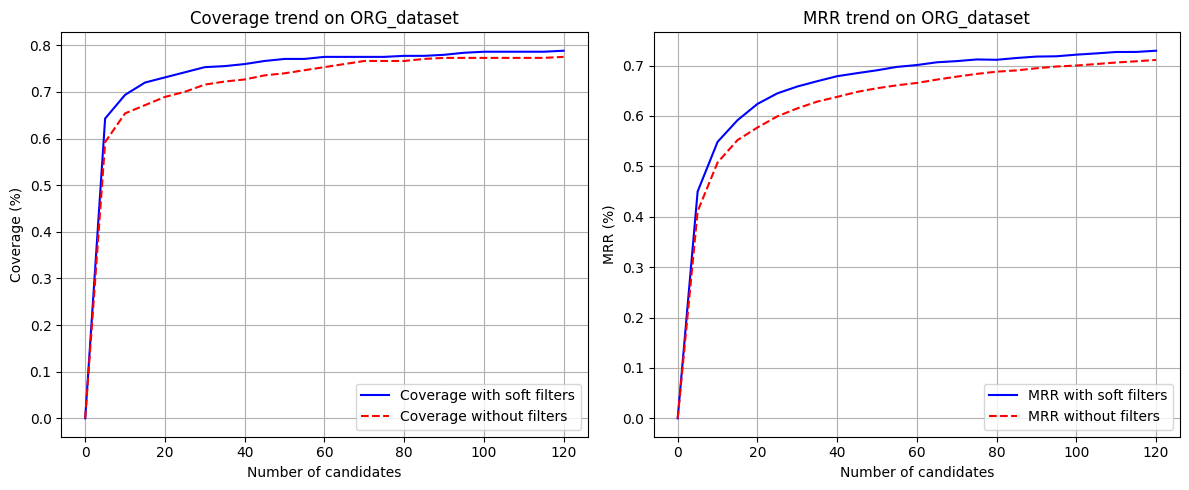

In [11]:
import matplotlib.pyplot as plt

# Extract x and y values
x_values = list(range(0, 125, 5))

# Coverage values
y_cov_values = [el[0] for el in cov_mrr_values.values()]
y_cov_values_no_filters = [el[0] for el in cov_mrr_values_no_filters.values()]

# MRR values
y_mrr_values = [el[1] for el in cov_mrr_values.values()]
y_mrr_values_no_filters = [el[1] for el in cov_mrr_values_no_filters.values()]

# Create the figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Coverage (First)
axes[0].plot(x_values, y_cov_values, linestyle='-', color='b', label='Coverage with soft filters')
axes[0].plot(x_values, y_cov_values_no_filters, linestyle='--', color='r', label='Coverage without filters')
axes[0].set_xlabel("Number of candidates")
axes[0].set_ylabel("Coverage (%)")
axes[0].set_title("Coverage trend on ORG_dataset")
axes[0].legend()
axes[0].grid(True)

# Plot MRR (Second)
axes[1].plot(x_values, y_mrr_values, linestyle='-', color='b', label='MRR with soft filters')
axes[1].plot(x_values, y_mrr_values_no_filters, linestyle='--', color='r', label='MRR without filters')
axes[1].set_xlabel("Number of candidates")
axes[1].set_ylabel("MRR (%)")
axes[1].set_title("MRR trend on ORG_dataset")
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


# DA QUI IN POI TUTTO DA RIVEDERE

## NER type vs NER type

In [4]:
import json 

json_file_path = "/home/lamapi/lamAPI/data/Downloads/Downloads/_Round4/R4_WD_query_type.json"

with open(json_file_path, "r") as file:
    HTR2_type = json.load(file)


tables_path = "/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/Round4_2020/all_tables/"
cea_file = '/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/Round4_2020/gt/cea.csv'
cta_file = '/home/lamapi/lamAPI/data/Downloads/Downloads/Downloads/Round4_2020/gt/cta.csv'


os.listdir(tables_path)
# Initialize logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Read the cea_file and create a key-value dictionary
df_cea = pd.read_csv(cea_file, header=None)
df_cea["key"] = df_cea[0] + " " + df_cea[1].astype(str) + " " + df_cea[2].astype(str)
df_cea["key_col"] = df_cea[0] + " " + df_cea[2].astype(str)
cea_values_dict = dict(zip(df_cea["key_col"].values, df_cea[3].values))

cea_keys_set = set(df_cea["key"].values)
cea_values_dict_cell = dict(zip(df_cea["key"].values, df_cea[3].values))

# Function to process a single table file
def process_table_file(table_file):
    try:
        table_name = os.path.splitext(os.path.basename(table_file))[0]
        df = pd.read_csv(table_file)
        qid_to_value = {}

        for row in range(df.shape[0]):
            for col in range(df.shape[1]):
                key = f"{table_name} {row+1} {col}"
                if key in cea_keys_set:
                    cell_value = df.iloc[row, col]
                    qid = cea_values_dict_cell[key].split('/')[-1]  # Extract the QID from the URL
                    qid_to_value[cell_value] = qid
                    break  # Exit inner loop early as only one match per row/col is needed

        return qid_to_value
    except Exception as e:
        logging.error(f"Error processing {table_file}: {e}")
        return {}

# List of table files
table_files = [
    os.path.join(tables_path, table)
    for table in os.listdir(tables_path)
    if not table.startswith('.')
]

# Process tables sequentially
HTR2_id_to_name = {}
for table_file in tqdm(table_files, desc="Processing tables"):
    local_key_to_cell = process_table_file(table_file)
    HTR2_id_to_name.update(local_key_to_cell)

Processing tables: 100%|██████████| 22387/22387 [00:33<00:00, 660.70it/s]


### Hard query construction

In [5]:
### NO NER MAPPINGFOR QUERY TYPE

def get_query(name, value):
    name = str(name).replace('"', ' ')
    if value is not None:
        # hard filtering constraint
        query_dict = {
            "query": {
                "bool": {
                    "must": [
                        {"match": {"name": {"query": name, "boost": 2.0}}}
                    ]
                }
            }
        }
        params = {
            'name': name,
            'token': 'lamapi_demo_2023',
            'kg': 'wikidata',
            'limit': 100,
            'query': json.dumps(query_dict),  # Convert the query dictionary to a JSON string
            'sort': [
                '{"popularity": {"order": "desc"}}'
            ]
        }
    
        return params
    return None

queries = []
for name, id  in tqdm(HTR2_id_to_name.items()):
    if id in HTR2_type:
        types_list = HTR2_type[id]

        ########################################################
        ##  modificare se types_list è una lista di tipi
        ########################################################
    
        query = get_query(name, types_list)
        if query is None:
            continue
        queries.append((query, id, types_list))



100%|██████████| 352171/352171 [00:00<00:00, 547015.60it/s]


### Soft query construction

In [6]:
###################################################################
## RIDUCI I TIPI ESTESI A 20 ALTRIMENTI LA GET NON LI REGGE
###################################################################

### NO NER MAPPING FOR QUERY TYPE

def get_query(name, value):
    name = str(name).replace('"', ' ')  # Replace double quotes with spaces

    should_clause = []
    if value:
        if isinstance(value, list):
            should_clause = [{"term": {"extended_WDtypes": v}} for v in value[:20]]
        else:
            should_clause = [{"term": {"extended_WDtypes": value}}]

    query_dict = {
        "query": {
            "bool": {
                "must": [
                    {"match": {"name": {"query": name, "boost": 2.0}}}
                ],
                "should": should_clause
            }
        }
    }

    params = {
        'name': name,
        'token': 'lamapi_demo_2023',
        'kg': 'wikidata',
        'limit': 100,
        'query': json.dumps(query_dict),  # Compact JSON
        'sort': ['{"popularity": {"order": "desc"}}']
    }

    return params

queries = []
for name, id in tqdm(HTR2_id_to_name.items()):
    if id in HTR2_type:
        types_list = HTR2_type[id]

        ########################################################
        ##  modificare se types_list è una lista di tipi
        ########################################################
    
        query = get_query(name, types_list)

        queries.append((query, id, types_list))



100%|██████████| 352171/352171 [00:00<00:00, 597132.46it/s]


In [7]:
import aiohttp
import asyncio
import backoff
import nest_asyncio
import random
from tqdm import tqdm
import numpy as np

# Assume queries is a list of tuples [(param1, id1), (param2, id2), ...]

failed_queries = {}
url = 'http://localhost:5000/lookup/entity-retrieval'

# Backoff decorator for handling retries with exponential backoff
@backoff.on_exception(
    backoff.expo, 
    (aiohttp.ClientError, aiohttp.http_exceptions.HttpProcessingError, asyncio.TimeoutError), 
    max_tries=10, 
    max_time=400
)
async def fetch(session, url, params, headers, semaphore):
    async with semaphore:
        # Convert all params to str, int, or float
        #params = {k: (int(v) if isinstance(v, np.integer) else str(v)) for k, v in params.items()}
        async with session.get(url, params=params, headers=headers, timeout=50) as response:
            try:
                response.raise_for_status()  # Raises an exception for 4XX/5XX status codes
                return await response.json()
            except asyncio.TimeoutError:
                print(f"Request timed out for params: {params}")
                return []  # Return an empty list to handle the timeout gracefully
            except aiohttp.ClientError as e:
                print(f"ClientError for params : {str(e)}")
                return []
            except Exception as e:
                print(f"Unexpected error for params {params}: {str(e)}")
                return []
async def process_item(session, url, id, headers, params, semaphore, pbar,limit):
    try:
        data = await fetch(session, url, params, headers, semaphore)

    except aiohttp.ClientResponseError as e:
        if e.status == 404:
            print(f"404 Error: Resource not found for '{id}'")
            asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
            return 0, 0
        else:
            raise  # Re-raise the exception for other status codes

    num_result = len(data) if data else 0


    ###################################################
    ## scandisco il candidate set in cui ho già fatto 
    ## l'overlapping dei tipi
    ###################################################
    
    #print(f"------------>{eval(params['query'])['query']['bool']['must'][1]} - # candidate: {len(data)}")
    if data and any(entity['id'] == id for entity in data):
        params['limit'] = limit
        try:
            data_new = await fetch(session, url, params, headers, semaphore)
        except aiohttp.ClientResponseError as e:
            if e.status == 404:
                print(f"404 Error: Resource not found for '{id}'")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                return 0, 0
            else:
                raise  # Re-raise the exception for other status codes

        for item in data_new:
            if id == item.get('id'):
                #print(f"{item.get('name')}: es_score({item.get('es_score', 0)}), pos_score({item.get('pos_score', 0)})-> {item.get('description')}")
                asyncio.get_event_loop().call_soon_threadsafe(pbar.update, 1)
                pos_score = item.get('pos_score', 0)
                if pos_score:
                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                else:
                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                return mrr_increment, 1

        return 0, 0
    return -1, -1

async def main(queries, url, pbar, failed_queries, limit):
    headers = {'accept': 'application/json'}
    semaphore = asyncio.Semaphore(50)  # Limit to 50 concurrent requests
    m_mrr = 0
    cont_el = 0

    async with aiohttp.ClientSession() as session:
        tasks = []
        for param, id, _ in queries:
            tasks.append(process_item(session, url, id, headers, param, semaphore, pbar,limit))
        
        results = await asyncio.gather(*tasks)
        found = 0
        
        for (mrr_increment, count), (param, id, item_NERtype) in zip(results, queries):
            if found == 1000:
                break
            if mrr_increment == 0 and count == 0:
                failed_queries[id] = (id, item_NERtype)
                
                # Parse the string into a Python dictionary
                query_dict = json.loads(param['query'])

                # Modify the "match" field
                if "query" in query_dict and "bool" in query_dict["query"] and "must" in query_dict["query"]["bool"]:
                    for condition in query_dict["query"]["bool"]["must"]:
                        if "match" in condition and "name" in condition["match"]:
                            condition["match"]["name"]["fuzziness"] = "AUTO"

                # Convert back to JSON string
                param['query'] = json.dumps(query_dict)
                param['limit'] = limit

                response = requests.get(url, params=param)
                if response.status_code == 200:
                    data = response.json()
                    #print("after call")
                    num_result = len(data) if data else 0
                    if data:
                        for item in data:
                            if id == item.get('id'):
                                pbar.update(1)  # No need to await here
                                pos_score = item.get('pos_score', 0)
                                if pos_score:
                                    mrr_increment = (num_result - (pos_score * num_result)) / num_result
                                else:
                                    mrr_increment = 1 / num_result  # Assume worst case for MRR if pos_score is 0
                            
                found+=1
                m_mrr += mrr_increment
                cont_el += count 
            elif mrr_increment > 0 and count > 0:
                found+=1
                m_mrr += mrr_increment
                cont_el += count
            else:
                continue

        asyncio.get_event_loop().call_soon_threadsafe(pbar.close)

    print(f"{found} found")
    print(f"Coverage of 2T: {cont_el / (found)}")
    print(f"Measure Reciprocal Rank of 2T: {m_mrr / (found)}")
    return cont_el / (found), m_mrr / (found)


# Check if there's already a running event loop
if __name__ == "__main__":
    nest_asyncio.apply()  # Apply nest_asyncio
    cov_mrr_values = {}
    try:
        for el in range(10,200,10):
            pbar = tqdm(total=len(queries))
            cov_tmp, mrr_tmp = asyncio.run(main(queries, url, pbar, failed_queries, el))
            cov_mrr_values[el] = (cov_tmp, mrr_tmp)
            print(f"limit {el} : {(cov_tmp, mrr_tmp)}")
    except RuntimeError:  # For environments like Jupyter
        loop = asyncio.get_event_loop()
        loop.run_until_complete(main(queries, url, pbar, failed_queries))


 11%|█▏        | 3134/27777 [07:35<59:40,  6.88it/s]   


1000 found
Coverage of 2T: 0.974
Measure Reciprocal Rank of 2T: 0.8603469999999869
limit 10 : (0.974, 0.8603469999999869)


 11%|█▏        | 3134/27777 [04:36<36:11, 11.35it/s]   


1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9200850000000108
limit 20 : (1.0, 0.9200850000000108)


 11%|█▏        | 3134/27777 [04:44<37:19, 11.00it/s]   


...

1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9692700000000168
limit 170 : (1.0, 0.9692700000000168)


 11%|█▏        | 3134/27777 [08:45<1:08:52,  5.96it/s] 


1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9693840000000155
limit 180 : (1.0, 0.9693840000000155)


 11%|█▏        | 3134/27777 [09:35<1:15:23,  5.45it/s] 

1000 found
Coverage of 2T: 1.0
Measure Reciprocal Rank of 2T: 0.9701630000000042
limit 190 : (1.0, 0.9701630000000042)


In [8]:
print("WITh FILTERS")
print([v[1] for v in cov_mrr_values.values()])

WITh FILTERS
[0.8603469999999869, 0.9200850000000108, 0.9395949999999914, 0.9487750000000127, 0.9543310000000104, 0.9577489999999825, 0.9607469999999935, 0.9620849999999934, 0.9640210000000053, 0.965094000000007, 0.9661239999999934, 0.9670599999999888, 0.9672929999999907, 0.9681890000000156, 0.9683340000000149, 0.9691470000000144, 0.9692700000000168, 0.9693840000000155, 0.9701630000000042]


In [1]:
cov_mrr_values_filters = [0.8603469999999869, 0.9200850000000108, 0.9395949999999914, 0.9487750000000127, 0.9543310000000104, 0.9577489999999825, 0.9607469999999935, 0.9620849999999934, 0.9640210000000053, 0.965094000000007, 0.9661239999999934, 0.9670599999999888, 0.9672929999999907, 0.9681890000000156, 0.9683340000000149, 0.9691470000000144, 0.9692700000000168, 0.9693840000000155, 0.9701630000000042]
cov_mrr_values = [0.8350489999999882, 0.9099820000000107, 0.9288389999999918, 0.9388050000000122, 0.9449360000000101, 0.948619999999983, 0.9522979999999938, 0.9541919999999935, 0.9556040000000049, 0.9570870000000067, 0.9584459999999937, 0.9596469999999891, 0.960134999999991, 0.961215000000015, 0.9615470000000149, 0.962486000000014, 0.9603720000000161, 0.9607450000000151, 0.9617060000000036]

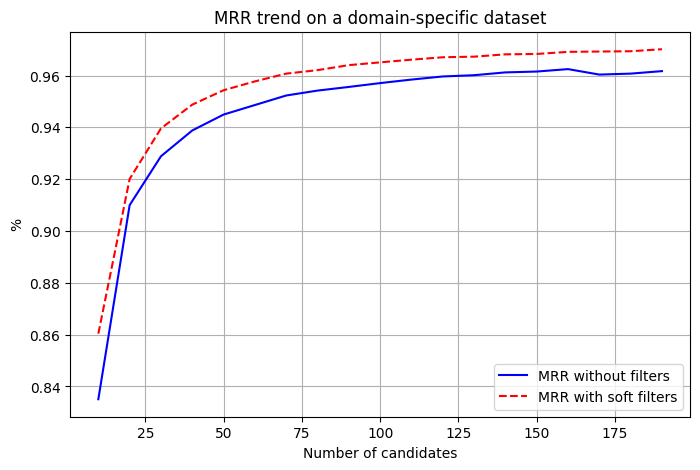

In [2]:
import matplotlib.pyplot as plt

# Extract x and y values
x_values = list(range(10,200,10))
y_values = [el for el in cov_mrr_values]
y_values_filters = [el for el in list(cov_mrr_values_filters)]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, linestyle='-', color='b', label='MRR without filters')
plt.plot(x_values, y_values_filters, linestyle='--', color='r', label='MRR with soft filters')

# Labels and title
plt.xlabel("Number of candidates")
plt.ylabel("%")
plt.title("MRR trend on a domain-specific dataset")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

## Extended WD type vs WD type

In [14]:
# for each WD type inserted from the user (WD_query_type taken from CEA) now we retrieve the extended WD types until the root
# given the list of the ext_types we do the overlap with the ext_types taken from lamAPI with HARD and SOFT query

ext_query_types = []

for entity_id, type_str in WD_query_type.items():
    #print(f"{type_str}: {get_type_id(type_str)}")
    
    entity_name = key_to_cell[list(WD_query_type.keys())[0]]
    ext_query_types += list(set(retrieve_superclasses(get_type_id(type_str))))
    
    # query a lamapi dove specifico nel filtro il tipo

    # entity_id è il ground truth
    WD_candidate_types = WD_types(entity_id)  # WD_types() interroga il servizio types() ma forse è sbagliato (da implementare lato server non client)
print(ext_query_types)


KeyboardInterrupt: 

In [15]:
ext_query_types

['Q53617489',
 'Q98119401',
 'Q16334295',
 'Q20937557',
 'Q2897903',
 'Q2217301',
 'Q7725310',
 'Q1002697',
 'Q117208263',
 'Q732577',
 'Q24229398',
 'Q16887380',
 'Q15621286',
 'Q11032',
 'Q1554231',
 'Q106668099',
 'Q99527517',
 'Q43229',
 'Q3523102',
 'Q286583',
 'Q1193236',
 'Q121182',
 'Q61961344',
 'Q7048977',
 'Q58415929',
 'Q1639378',
 'Q49848',
 'Q28877',
 'Q2424752',
 'Q131085629',
 'Q488383',
 'Q58778',
 'Q117208269',
 'Q12774177',
 'Q35825432',
 'Q115668308',
 'Q854457',
 'Q26907166',
 'Q17538423',
 'Q31464082',
 'Q16686448',
 'Q107435521',
 'Q47461344',
 'Q37866906',
 'Q17172633',
 'Q106559804',
 'Q28314507',
 'Q386724',
 'Q17537576',
 'Q119648442',
 'Q234460',
 'Q5127848',
 'Q35120',
 'Q17489659',
 'Q340169',
 'Q16334298',
 'Q1261026',
 'Q16889133',
 'Q103940464',
 'Q11033',
 'Q11474',
 'Q53617489',
 'Q53617407',
 'Q193395',
 'Q28555911',
 'Q2897903',
 'Q9158768',
 'Q6671777',
 'Q10683158',
 'Q251473',
 'Q99527517',
 'Q96791170',
 'Q337060',
 'Q8205328',
 'Q104450446',
 '

## WD type vs NER type

In [ ]:
# for each WD type inserted from the user (WD_WD_query_type taken from CEA) now we retrieve the extended WD types until the root
# given the list of the ext_types we do the overlap with the ext_types taken from lamAPI with HARD and SOFT query

False

In [25]:
retrieve_superclasses("Q12299841")

{'Q12299841': 'cricketer',
 'Q2066131': 'athlete',
 'Q18536342': 'competitive player',
 'Q50995749': 'sportsperson',
 'Q4197743': 'player',
 'Q215627': 'person',
 'Q830077': 'subject',
 'Q795052': 'individual',
 'Q3778211': 'legal person',
 'Q53617489': 'independent continuant',
 'Q7239': 'organism',
 'Q24229398': 'agent',
 'Q106559804': 'person or organization',
 'Q103940464': 'continuant',
 'Q223557': 'physical object',
 'Q66394244': 'physical anatomical entity',
 'Q4406616': 'concrete object',
 'Q53617407': 'material entity',
 'Q27043950': 'anatomical entity',
 'Q488383': 'object',
 'Q35120': 'entity'}

In [8]:
cta_values_dict

{'58891288_0_1117541047012405958 1': 'http://dbpedia.org/ontology/Film',
 '8468806_0_4382447409703007384 1': 'http://dbpedia.org/ontology/Lake',
 '50245608_0_871275842592178099 0': 'http://dbpedia.org/ontology/Film',
 '14067031_0_559833072073397908 1': 'http://dbpedia.org/ontology/Language',
 '8286121_0_8471791395229161598 0': 'http://dbpedia.org/ontology/Country',
 '39759273_0_1427898308030295194 1': 'http://dbpedia.org/ontology/Film',
 '14380604_4_3329235705746762392 1': 'http://dbpedia.org/ontology/Company',
 '20135078_0_7570343137119682530 3': 'http://dbpedia.org/ontology/Person',
 '29414811_6_8221428333921653560 1': 'http://dbpedia.org/ontology/VideoGame',
 '34041816_1_4749054164534706977 2': 'http://dbpedia.org/ontology/City',
 '14067031_0_559833072073397908 7': 'http://dbpedia.org/ontology/Currency',
 '71137051_0_8039724067857124984 0': 'http://dbpedia.org/ontology/Bird',
 '29414811_2_4773219892816395776 1': 'http://dbpedia.org/ontology/VideoGame',
 '99070098_0_20748727413026969

In [11]:
cea_values_dict

{'50245608_0_871275842592178099 0': 'https://www.wikidata.org/entity/Q46551',
 '22864497_0_8632623712684511496 0': 'https://www.wikidata.org/entity/Q6738126',
 '66009064_0_9148652238372261251 0': 'https://www.wikidata.org/entity/Q1094988',
 '21362676_0_6854186738074119688 1': 'https://www.wikidata.org/entity/Q463832',
 '40534006_0_4617468856744635526 1': 'https://www.wikidata.org/entity/Q452590',
 '36102169_0_7739454799295072814 2': 'https://www.wikidata.org/entity/Q1978200',
 '53822652_0_5767892317858575530 1': 'https://www.wikidata.org/entity/Q200396',
 '60319454_0_3938426910282115527 0': 'https://www.wikidata.org/entity/Q69581',
 '8468806_0_4382447409703007384 1': 'https://www.wikidata.org/entity/Q1546823',
 '33401079_0_9127583903019856402 0': 'https://www.wikidata.org/entity/Q154538',
 '99070098_0_2074872741302696997 1': 'https://www.wikidata.org/entity/Q4920755',
 '50270082_0_444360818941411589 1': 'https://www.wikidata.org/entity/Q114468',
 '29414811_12_251152470253168163 1': 'ht